## PT Dynamic Gene Analysis Along Saved Diffusion Pseudotime

This notebook implements a simple continuous-expression analysis modeled on the seminiferous-cycle strategy used in the testis paper, but adapted to proximal tubule pseudospace. Tubules are ordered by the previously saved `pt_scanpy_dpt` coordinate rather than reclustered into discrete states. Before testing, genes are restricted to those detected in at least 3% of PT tubules so that rare dropout-driven features are excluded from the dynamic-gene scan. Expression is averaged in pseudotime bins, smoothed with a short moving-average window, and tested against a permutation null generated by shuffling tubule pseudotime labels. Genes whose observed smoothed curves leave the 99% permutation envelope across a sufficiently long contiguous stretch of proximal-tubule pseudospace are called dynamic. Dynamic genes are then hierarchically grouped by trajectory shape, and each cluster can be summarized by GO enrichment.

The notebook is written to emphasize readable outputs: a cohort summary table, the top dynamic genes ranked by contiguous out-of-envelope span, a clustered heatmap of dynamic trajectories, representative cluster profiles, normalized marker-validation plots for canonical PT segment genes, and `gseapy`/Enrichr enrichment tables for each dynamic-gene module.

In [7]:
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.ndimage import uniform_filter1d
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from sklearn.cluster import AgglomerativeClustering

sns.set_theme(style='white', context='talk')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / 'data'
INPUT_PATH = DATA_DIR / 'all_tubules_scanpy_dpt.h5ad'
OUTPUT_DIR = DATA_DIR / 'clustering_comparison' / 'pt_dynamic_gene_analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    'seed': 7,
    'pseudotime_col': 'pt_scanpy_dpt',
    'broad_label_col': 'broad_tubule_marker_call',
    'subset_label': 'PT',
    'expression_layer': 'lognorm',
    'gene_test_mode': 'highly_variable',  # {'highly_variable', 'all_expressed'}
    'min_presence_fraction': 0.03,
    'min_detected_tubules': None,
    'min_mean_expression': 0.01,
    'n_bins': 50,
    'smooth_window_bins': 5,
    'n_permutations': 1000,
    'null_ci': 0.99,
    'min_contiguous_fraction': 0.12,
    'n_clusters': 12,
    'top_dynamic_table': 25,
    'top_genes_per_cluster_plot': 4,
    'marker_validation_scale': 'zscore',  # {'zscore', 'minmax', 'raw'}
    'enrichr_libraries': [
        'GO_Biological_Process_2023',
        'KEGG_2021_Mouse',
        'Reactome_2022',
        'MSigDB_Hallmark_2020',
    ],
    'enrichment_top_terms': 10,
}

PT_MARKER_GROUPS = {
    'PT_S1': ['Slc5a2', 'Slc5a12'],
    'PT_S2': ['Slc22a8', 'Slc22a6', 'Slc13a3', 'Slc22a2', 'Slc34a1'],
    'PT_S3': ['Slc7a13', 'Slc5a8', 'Slc38a3', 'Hao2', 'Pck1', 'Acsm3'],
}

adata_all = sc.read_h5ad(INPUT_PATH)
required_obs = [CONFIG['broad_label_col'], CONFIG['pseudotime_col']]
missing_obs = [col for col in required_obs if col not in adata_all.obs.columns]
if missing_obs:
    raise KeyError(f'Missing required obs columns in {INPUT_PATH.name}: {missing_obs}')

pt_mask = (
    adata_all.obs[CONFIG['broad_label_col']].astype(str).eq(CONFIG['subset_label'])
    & adata_all.obs[CONFIG['pseudotime_col']].notna()
).to_numpy()
pt_order = adata_all.obs.loc[pt_mask].sort_values(CONFIG['pseudotime_col']).index
adata_pt = adata_all[pt_order].copy()

print(f'Loaded {INPUT_PATH.relative_to(PROJECT_DIR)}')
print(f'PT tubules retained for analysis: {adata_pt.n_obs:,}')
print(f'Genes available: {adata_pt.n_vars:,}')
print(f'Output directory: {OUTPUT_DIR.relative_to(PROJECT_DIR)}')

Loaded data/all_tubules_scanpy_dpt.h5ad
PT tubules retained for analysis: 19,999
Genes available: 15,704
Output directory: data/clustering_comparison/pt_dynamic_gene_analysis


In [8]:
def get_expression_matrix(adata, layer=None):
    if layer is not None and layer in adata.layers:
        matrix = adata.layers[layer]
    else:
        matrix = adata.X
    if sp.issparse(matrix):
        return matrix.tocsr().astype(np.float32)
    return sp.csr_matrix(np.asarray(matrix, dtype=np.float32))


def make_one_hot(bin_ids, n_bins):
    rows = np.arange(bin_ids.size, dtype=np.int32)
    cols = np.asarray(bin_ids, dtype=np.int32)
    data = np.ones(bin_ids.size, dtype=np.float32)
    return sp.csr_matrix((data, (rows, cols)), shape=(bin_ids.size, n_bins), dtype=np.float32)


def compute_bin_means(matrix, one_hot, counts):
    sums = (matrix.T @ one_hot).astype(np.float32)
    if sp.issparse(sums):
        sums = sums.toarray()
    counts = np.maximum(counts, 1.0).astype(np.float32)
    return sums / counts[np.newaxis, :]


def smooth_curves(curves, window):
    return uniform_filter1d(curves, size=window, axis=1, mode='nearest')


def longest_true_run(mask):
    longest = 0
    current = 0
    for value in mask:
        if value:
            current += 1
            longest = max(longest, current)
        else:
            current = 0
    return longest


def zscore_rows(values):
    mean = values.mean(axis=1, keepdims=True)
    std = values.std(axis=1, keepdims=True)
    std[std == 0] = 1.0
    return (values - mean) / std


def select_gene_mask(adata, matrix, config):
    detected = np.asarray((matrix > 0).sum(axis=0)).ravel()
    means = np.asarray(matrix.mean(axis=0)).ravel()
    min_detected = config['min_detected_tubules']
    if min_detected is None:
        min_detected = int(np.ceil(config['min_presence_fraction'] * adata.n_obs))
    keep = (detected >= min_detected) & (means >= config['min_mean_expression'])
    if config['gene_test_mode'] == 'highly_variable' and 'highly_variable' in adata.var.columns:
        keep &= adata.var['highly_variable'].fillna(False).to_numpy()
    return keep


def run_dynamic_permutation_test(adata, config):
    rng = np.random.default_rng(config['seed'])
    pseudotime = adata.obs[config['pseudotime_col']].to_numpy(dtype=np.float32)
    pseudotime = np.clip(pseudotime, 0.0, 1.0)
    n_bins = config['n_bins']
    bin_ids = np.floor(pseudotime * n_bins).astype(int)
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)
    bin_centers = (np.arange(n_bins, dtype=np.float32) + 0.5) / n_bins

    matrix = get_expression_matrix(adata, layer=config['expression_layer'])
    gene_mask = select_gene_mask(adata, matrix, config)
    matrix = matrix[:, gene_mask]
    gene_names = adata.var_names[gene_mask].to_numpy()

    counts = np.bincount(bin_ids, minlength=n_bins).astype(np.float32)
    observed_one_hot = make_one_hot(bin_ids, n_bins)
    observed_bin_means = compute_bin_means(matrix, observed_one_hot, counts)
    observed_smooth = smooth_curves(observed_bin_means, config['smooth_window_bins'])

    shuffled_bins = np.empty((config['n_permutations'], adata.n_obs), dtype=np.int16)
    for idx in range(config['n_permutations']):
        shuffled_bins[idx] = rng.permutation(bin_ids)

    alpha_tail = (1.0 - config['null_ci']) / 2.0
    lower = np.empty_like(observed_smooth, dtype=np.float32)
    upper = np.empty_like(observed_smooth, dtype=np.float32)
    perm_center = np.empty_like(observed_smooth, dtype=np.float32)
    chunk_size = 256

    for start in range(0, matrix.shape[1], chunk_size):
        stop = min(start + chunk_size, matrix.shape[1])
        matrix_chunk = matrix[:, start:stop]
        perm_curves = np.empty((config['n_permutations'], stop - start, n_bins), dtype=np.float32)
        for perm_idx in range(config['n_permutations']):
            perm_one_hot = make_one_hot(shuffled_bins[perm_idx], n_bins)
            perm_means = compute_bin_means(matrix_chunk, perm_one_hot, counts)
            perm_curves[perm_idx] = smooth_curves(perm_means, config['smooth_window_bins'])
        lower[start:stop] = np.quantile(perm_curves, alpha_tail, axis=0).astype(np.float32)
        upper[start:stop] = np.quantile(perm_curves, 1.0 - alpha_tail, axis=0).astype(np.float32)
        perm_center[start:stop] = perm_curves.mean(axis=0).astype(np.float32)

    min_run_bins = max(1, int(np.ceil(config['min_contiguous_fraction'] * n_bins)))
    above = observed_smooth > upper
    below = observed_smooth < lower
    dynamic_records = []
    for gene_idx, gene in enumerate(gene_names):
        max_run = max(longest_true_run(above[gene_idx]), longest_true_run(below[gene_idx]))
        signed_deviation = observed_smooth[gene_idx] - perm_center[gene_idx]
        peak_bin = int(np.argmax(np.abs(signed_deviation)))
        dynamic_records.append({
            'gene': gene,
            'detected_tubules': int((matrix[:, gene_idx] > 0).sum()),
            'mean_expression': float(observed_bin_means[gene_idx].mean()),
            'max_run_bins': int(max_run),
            'max_run_fraction': float(max_run / n_bins),
            'peak_bin': peak_bin,
            'peak_pseudotime': float(bin_centers[peak_bin]),
            'peak_abs_deviation': float(np.max(np.abs(signed_deviation))),
            'dynamic': bool(max_run >= min_run_bins),
        })

    stats = pd.DataFrame(dynamic_records).sort_values(
        ['dynamic', 'max_run_bins', 'peak_abs_deviation'],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    return {
        'matrix': matrix,
        'gene_names': gene_names,
        'bin_ids': bin_ids,
        'bin_centers': bin_centers,
        'counts_per_bin': counts.astype(int),
        'observed_bin_means': observed_bin_means,
        'observed_smooth': observed_smooth,
        'lower': lower,
        'upper': upper,
        'perm_center': perm_center,
        'stats': stats,
        'min_run_bins': min_run_bins,
    }


def cluster_dynamic_genes(result, config):
    stats = result['stats'].copy()
    dynamic_mask = stats['dynamic'].to_numpy()
    dynamic_stats = stats.loc[dynamic_mask].copy()
    if dynamic_stats.empty:
        raise ValueError('No dynamic genes passed the permutation-based contiguous-run rule.')

    dynamic_gene_indices = dynamic_stats.index.to_numpy()
    dynamic_curves = result['observed_smooth'][dynamic_gene_indices]
    dynamic_z = zscore_rows(dynamic_curves)

    n_clusters = min(config['n_clusters'], dynamic_z.shape[0])
    clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    cluster_labels = clusterer.fit_predict(dynamic_z) + 1
    dynamic_stats['cluster'] = cluster_labels

    cluster_summary_rows = []
    for cluster_id in sorted(dynamic_stats['cluster'].unique()):
        mask = dynamic_stats['cluster'].to_numpy() == cluster_id
        cluster_curves = dynamic_z[mask]
        cluster_mean = cluster_curves.mean(axis=0)
        peak_bin = int(np.argmax(cluster_mean))
        trough_bin = int(np.argmin(cluster_mean))
        cluster_summary_rows.append({
            'cluster': cluster_id,
            'n_genes': int(mask.sum()),
            'peak_pseudotime': float(result['bin_centers'][peak_bin]),
            'trough_pseudotime': float(result['bin_centers'][trough_bin]),
            'mean_run_fraction': float(dynamic_stats.loc[mask, 'max_run_fraction'].mean()),
        })
    cluster_summary = pd.DataFrame(cluster_summary_rows).sort_values(['peak_pseudotime', 'cluster']).reset_index(drop=True)
    cluster_rank_map = {old: rank + 1 for rank, old in enumerate(cluster_summary['cluster'])}
    dynamic_stats['cluster'] = dynamic_stats['cluster'].map(cluster_rank_map)
    cluster_summary['cluster'] = cluster_summary['cluster'].map(cluster_rank_map)
    cluster_summary = cluster_summary.sort_values('cluster').reset_index(drop=True)

    order_within_cluster = []
    cluster_profiles = []
    representative_rows = []
    for cluster_id in sorted(dynamic_stats['cluster'].unique()):
        mask = dynamic_stats['cluster'].to_numpy() == cluster_id
        cluster_curves = dynamic_z[mask]
        cluster_mean = cluster_curves.mean(axis=0)
        cluster_profiles.append(pd.DataFrame({
            'cluster': cluster_id,
            'pseudotime': result['bin_centers'],
            'mean_zscore': cluster_mean,
        }))

        if cluster_curves.shape[0] > 2:
            corr = np.corrcoef(cluster_curves)
            corr = np.nan_to_num(corr, nan=0.0)
            distance = np.clip(1.0 - corr, 0.0, 2.0)
            linkage_matrix = linkage(squareform(distance, checks=False), method='average')
            local_order = leaves_list(linkage_matrix)
        else:
            local_order = np.arange(cluster_curves.shape[0])
        order_within_cluster.extend(dynamic_stats.index[mask][local_order].tolist())

        similarity = cluster_curves @ cluster_mean
        top_local = np.argsort(similarity)[::-1][: config['top_genes_per_cluster_plot']]
        for local_idx in top_local:
            row = dynamic_stats.loc[dynamic_stats.index[mask][local_idx], ['gene', 'cluster', 'peak_pseudotime', 'max_run_fraction']]
            representative_rows.append(row)

    dynamic_stats = dynamic_stats.set_index('gene')
    ordered_genes = result['stats'].loc[order_within_cluster, 'gene'].to_list()
    ordered_dynamic_stats = dynamic_stats.loc[ordered_genes].reset_index()
    cluster_profile_df = pd.concat(cluster_profiles, ignore_index=True)
    representative_df = pd.DataFrame(representative_rows).drop_duplicates('gene').sort_values(['cluster', 'peak_pseudotime'])

    return {
        'ordered_dynamic_stats': ordered_dynamic_stats,
        'ordered_genes': ordered_genes,
        'dynamic_z': pd.DataFrame(dynamic_z, index=result['stats'].loc[dynamic_gene_indices, 'gene'], columns=result['bin_centers']),
        'cluster_profile_df': cluster_profile_df,
        'representative_df': representative_df,
        'cluster_summary': cluster_summary,
    }


def build_marker_validation_table(result, marker_groups, scale='zscore'):
    gene_to_idx = {gene: idx for idx, gene in enumerate(result['gene_names'])}
    rows = []
    for group, genes in marker_groups.items():
        resolved = [gene for gene in genes if gene in gene_to_idx]
        if not resolved:
            continue
        curves = np.vstack([result['observed_smooth'][gene_to_idx[gene]] for gene in resolved]).astype(np.float32)
        if scale == 'zscore':
            curves = zscore_rows(curves)
            value_col = 'mean_zscore'
        elif scale == 'minmax':
            mins = curves.min(axis=1, keepdims=True)
            spans = curves.max(axis=1, keepdims=True) - mins
            spans[spans == 0] = 1.0
            curves = (curves - mins) / spans
            value_col = 'mean_scaled_signal'
        else:
            value_col = 'mean_signal'
        mean_curve = curves.mean(axis=0)
        for pseudotime, value in zip(result['bin_centers'], mean_curve):
            rows.append({
                'segment': group,
                'pseudotime': pseudotime,
                value_col: value,
                'value_column': value_col,
                'scale': scale,
                'n_genes': len(resolved),
            })
    return pd.DataFrame(rows)


def run_gseapy_enrichment_by_cluster(ordered_dynamic_stats, libraries, output_dir, organism='mouse'):
    try:
        import gseapy as gp
    except ImportError as exc:
        print(f'Skipping enrichment because gseapy is unavailable: {exc}')
        return pd.DataFrame()

    enrichment_tables = []
    for cluster_id, cluster_df in ordered_dynamic_stats.groupby('cluster'):
        genes = cluster_df['gene'].dropna().astype(str).drop_duplicates().tolist()
        if len(genes) < 5:
            continue
        for library in libraries:
            try:
                enr = gp.enrichr(
                    gene_list=genes,
                    gene_sets=library,
                    organism=organism,
                    outdir=None,
                    no_plot=True,
                    verbose=False,
                )
            except Exception as exc:
                print(f'Skipping {library} for cluster {cluster_id} because enrichr failed: {exc}')
                continue
            if enr is None or getattr(enr, 'results', None) is None or enr.results.empty:
                continue
            frame = enr.results.copy()
            frame.insert(0, 'cluster', cluster_id)
            frame.insert(1, 'library', library)
            enrichment_tables.append(frame)

    if not enrichment_tables:
        print('No enrichment results were returned by gseapy/Enrichr.')
        return pd.DataFrame()

    combined = pd.concat(enrichment_tables, ignore_index=True)
    sort_cols = [col for col in ['cluster', 'library', 'Adjusted P-value', 'P-value'] if col in combined.columns]
    if sort_cols:
        combined = combined.sort_values(sort_cols).reset_index(drop=True)
    combined.to_csv(output_dir / 'pt_dynamic_cluster_gseapy_enrichment.csv', index=False)
    return combined


def plot_summary_panels(adata, result, clustering, marker_validation, output_dir):
    summary_df = pd.DataFrame([
        {'metric': 'PT tubules analyzed', 'value': adata.n_obs},
        {'metric': 'Genes tested', 'value': len(result['gene_names'])},
        {'metric': 'Minimum PT presence fraction', 'value': CONFIG['min_presence_fraction']},
        {'metric': 'Dynamic genes', 'value': int(result['stats']['dynamic'].sum())},
        {'metric': 'Minimum contiguous bins', 'value': result['min_run_bins']},
        {'metric': 'Permutation count', 'value': CONFIG['n_permutations']},
    ])
    display(summary_df)

    top_dynamic = result['stats'].loc[result['stats']['dynamic']].head(CONFIG['top_dynamic_table']).copy()
    display(top_dynamic)
    top_dynamic.to_csv(output_dir / 'pt_top_dynamic_genes.csv', index=False)

    cluster_sizes = clustering['cluster_summary'].copy()
    display(cluster_sizes)
    cluster_sizes.to_csv(output_dir / 'pt_dynamic_cluster_sizes.csv', index=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [1.2, 1.8]})
    pseudotime = adata.obs[CONFIG['pseudotime_col']].to_numpy()
    axes[0].hist(pseudotime, bins=CONFIG['n_bins'], color='#4C78A8', edgecolor='white')
    axes[0].set_title('PT tubules along saved diffusion pseudotime')
    axes[0].set_xlabel('pt_scanpy_dpt')
    axes[0].set_ylabel('Tubules')

    if 'sample' in adata.obs.columns:
        counts = pd.Series(adata.obs['sample']).value_counts().sort_values(ascending=False)
        sns.barplot(x=counts.values, y=counts.index, ax=axes[1], color='#F58518')
        axes[1].set_title('PT tubules by sample')
        axes[1].set_xlabel('Tubules retained')
        axes[1].set_ylabel('Sample')
    else:
        axes[1].axis('off')
    fig.tight_layout()
    fig.savefig(output_dir / 'pt_cohort_summary.png', bbox_inches='tight')
    plt.show()

    heatmap_df = clustering['dynamic_z'].loc[clustering['ordered_genes']]
    ordered_clusters = clustering['ordered_dynamic_stats'].set_index('gene').loc[clustering['ordered_genes'], 'cluster']
    fig, ax = plt.subplots(figsize=(12, max(8, 0.03 * heatmap_df.shape[0])))
    sns.heatmap(
        heatmap_df,
        cmap='vlag',
        center=0,
        yticklabels=False,
        xticklabels=np.round(result['bin_centers'], 2),
        cbar_kws={'label': 'Row z-score'},
        ax=ax,
    )
    ax.set_title('Permutation-defined dynamic PT genes ordered by trajectory cluster')
    ax.set_xlabel('PT diffusion pseudotime bin center')
    ax.set_ylabel('Dynamic genes')
    for boundary in clustering['cluster_summary']['n_genes'].cumsum().to_numpy()[:-1]:
        ax.axhline(boundary, color='black', linewidth=0.5)
    fig.tight_layout()
    fig.savefig(output_dir / 'pt_dynamic_gene_heatmap.png', bbox_inches='tight')
    plt.show()

    cluster_profile_df = clustering['cluster_profile_df']
    cluster_ids = sorted(cluster_profile_df['cluster'].unique())
    fig, axes = plt.subplots(len(cluster_ids), 1, figsize=(12, 2.2 * len(cluster_ids)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, cluster_id in zip(axes, cluster_ids):
        cluster_data = cluster_profile_df[cluster_profile_df['cluster'] == cluster_id]
        ax.plot(cluster_data['pseudotime'], cluster_data['mean_zscore'], color='#4C78A8', linewidth=2)
        ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
        top_labels = clustering['representative_df'].loc[clustering['representative_df']['cluster'] == cluster_id, 'gene'].tolist()
        ax.set_ylabel(f'C{cluster_id}')
        ax.set_title(' | '.join(top_labels), fontsize=10, loc='left')
    axes[-1].set_xlabel('PT diffusion pseudotime')
    fig.suptitle('Representative dynamic-gene clusters across PT pseudospace', y=1.0)
    fig.tight_layout()
    fig.savefig(output_dir / 'pt_dynamic_cluster_profiles.png', bbox_inches='tight')
    plt.show()

    if not marker_validation.empty:
        fig, ax = plt.subplots(figsize=(10, 5))
        value_col = marker_validation['value_column'].iloc[0]
        sns.lineplot(data=marker_validation, x='pseudotime', y=value_col, hue='segment', linewidth=2.5, ax=ax)
        ax.set_title('Canonical PT segment markers validate the continuous ordering')
        ax.set_xlabel('PT diffusion pseudotime')
        y_labels = {
            'mean_zscore': 'Mean marker z-score',
            'mean_scaled_signal': 'Mean min-max scaled signal',
            'mean_signal': 'Smoothed mean expression',
        }
        ax.set_ylabel(y_labels.get(value_col, value_col))
        fig.tight_layout()
        fig.savefig(output_dir / 'pt_marker_validation.png', bbox_inches='tight')
        plt.show()

,metric,value
0,PT tubules analyzed,19999.00
1,Genes tested,1693.00
2,Minimum PT presence fraction,0.03
3,Dynamic genes,1439.00
4,Minimum contiguous bins,6.00
5,Permutation count,1000.00


,gene,detected_tubules,mean_expression,max_run_bins,max_run_fraction,peak_bin,peak_pseudotime,peak_abs_deviation,dynamic
0,Cyp2e1,8711,0.709091,37,0.74,46,0.93,0.695753,True
1,Clu,14191,1.668853,36,0.72,49,0.99,0.698529,True
2,Mt2,13162,1.311006,33,0.66,16,0.33,0.532704,True
3,Tmsb4x,16995,1.734605,33,0.66,49,0.99,0.482417,True
4,Jun,12854,1.045798,32,0.64,1,0.03,0.525024,True
5,Tmsb10,10457,0.800878,32,0.64,0,0.01,0.457472,True
6,Calb1,4738,0.360968,32,0.64,0,0.01,0.230993,True
7,Tmem52b,4128,0.268698,31,0.62,0,0.01,0.164361,True
8,Defb1,9290,0.825933,30,0.60,7,0.15,0.656171,True
9,S100a6,8059,0.748046,30,0.60,13,0.27,0.612328,True


,cluster,n_genes,peak_pseudotime,trough_pseudotime,mean_run_fraction
0,1,100,0.01,0.99,0.287400
1,2,162,0.01,0.99,0.267284
2,3,156,0.01,0.99,0.278974
3,4,261,0.01,0.99,0.264291
4,5,19,0.01,0.99,0.252632
5,6,117,0.21,0.99,0.285128
6,7,50,0.33,0.05,0.273200
7,8,140,0.35,0.99,0.272000
8,9,166,0.39,0.99,0.266988
9,10,127,0.41,0.09,0.280472


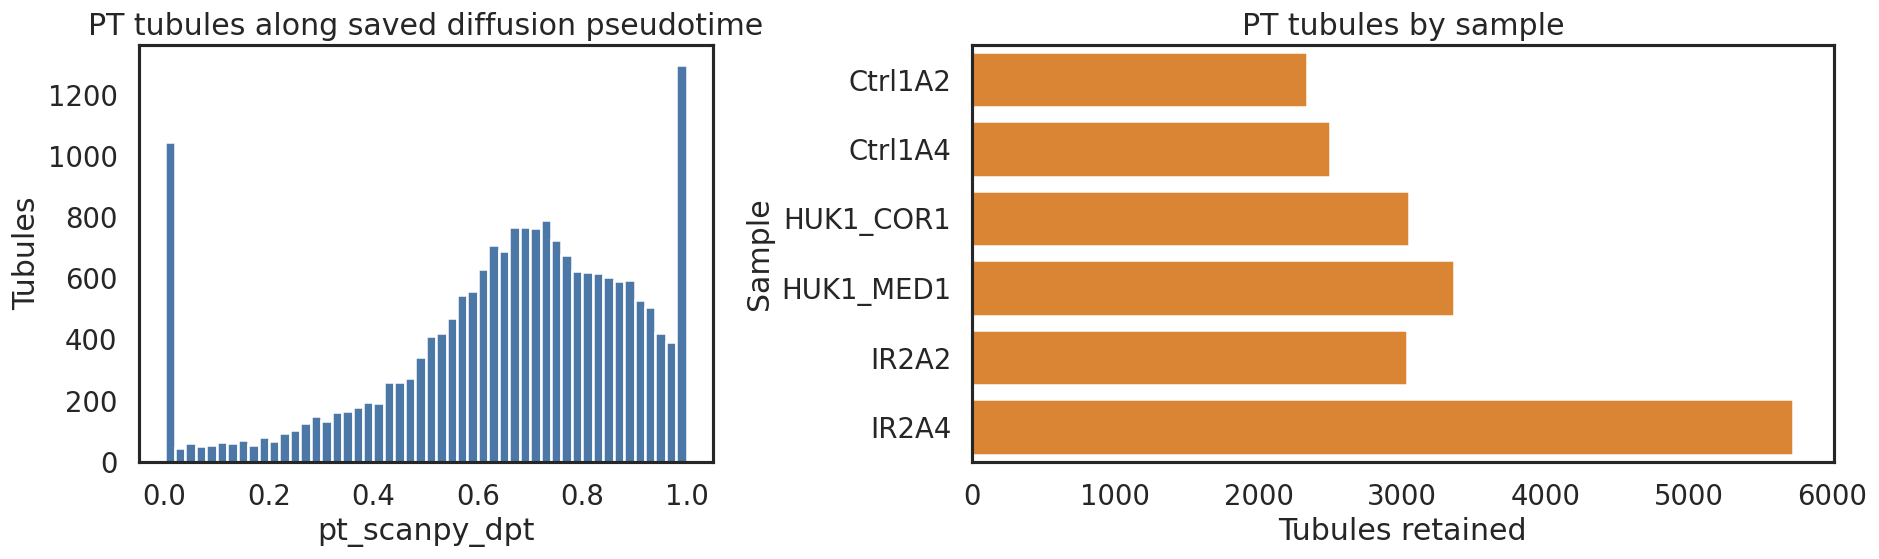

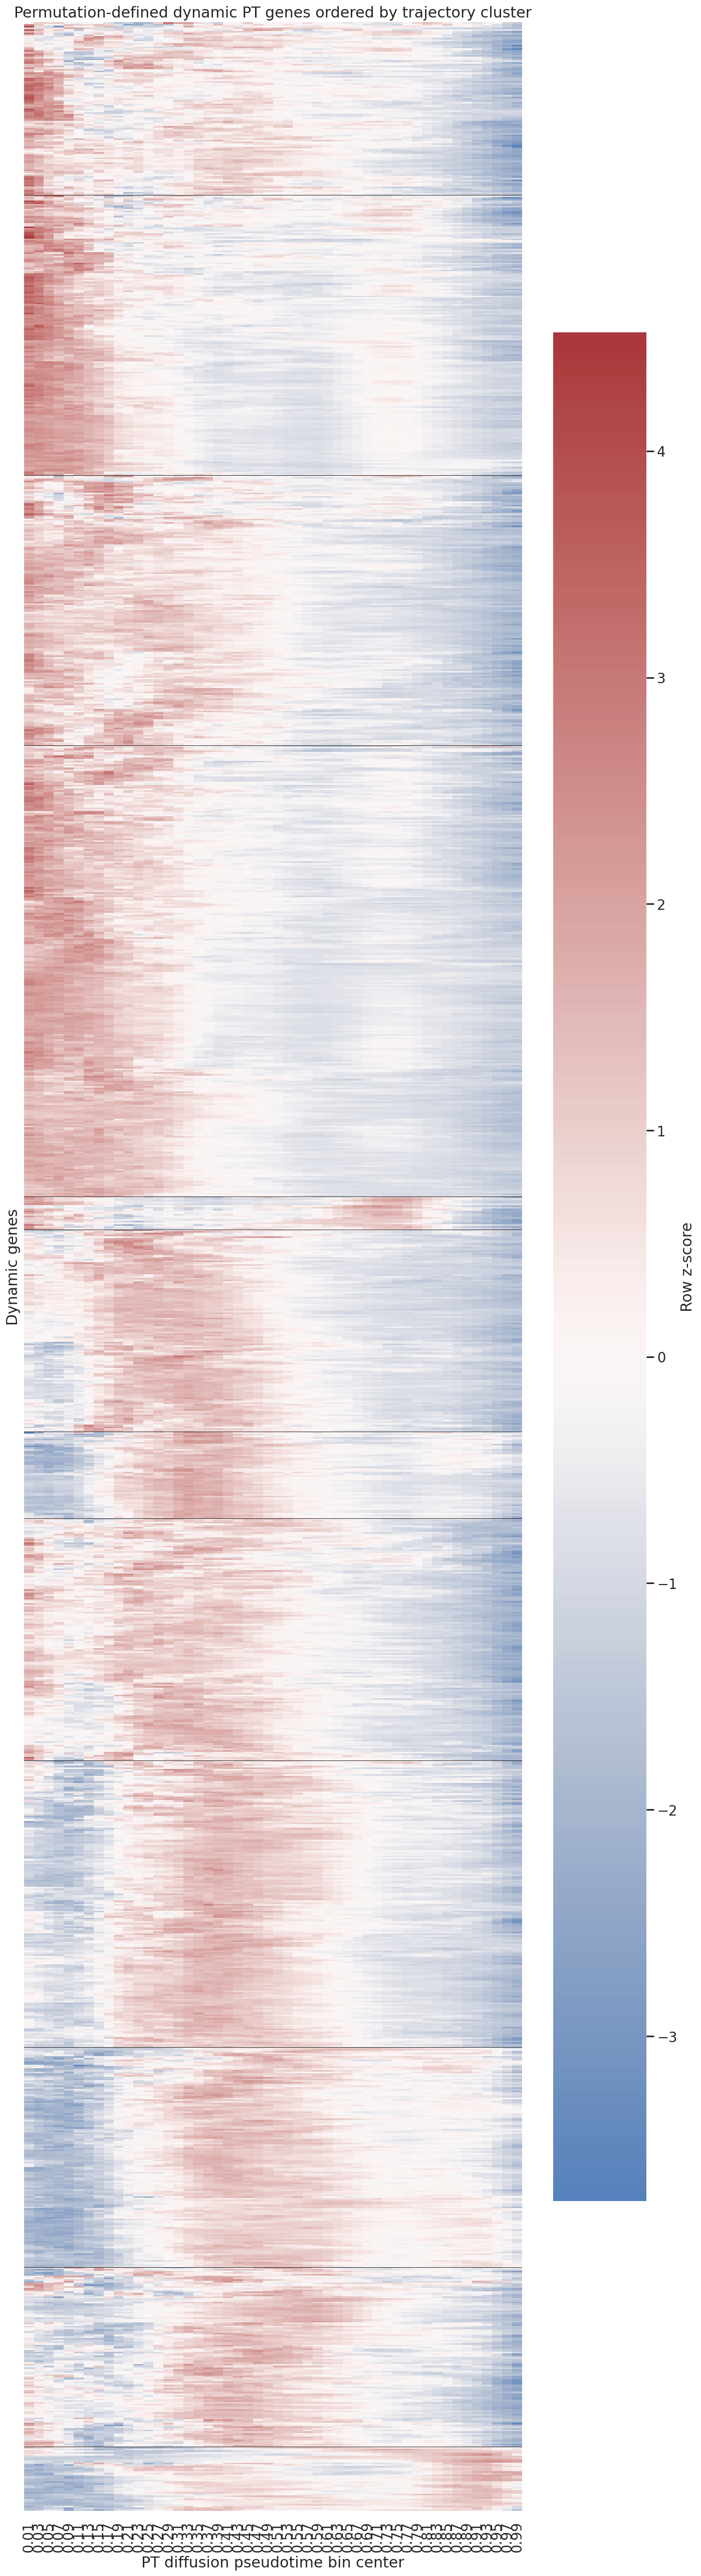

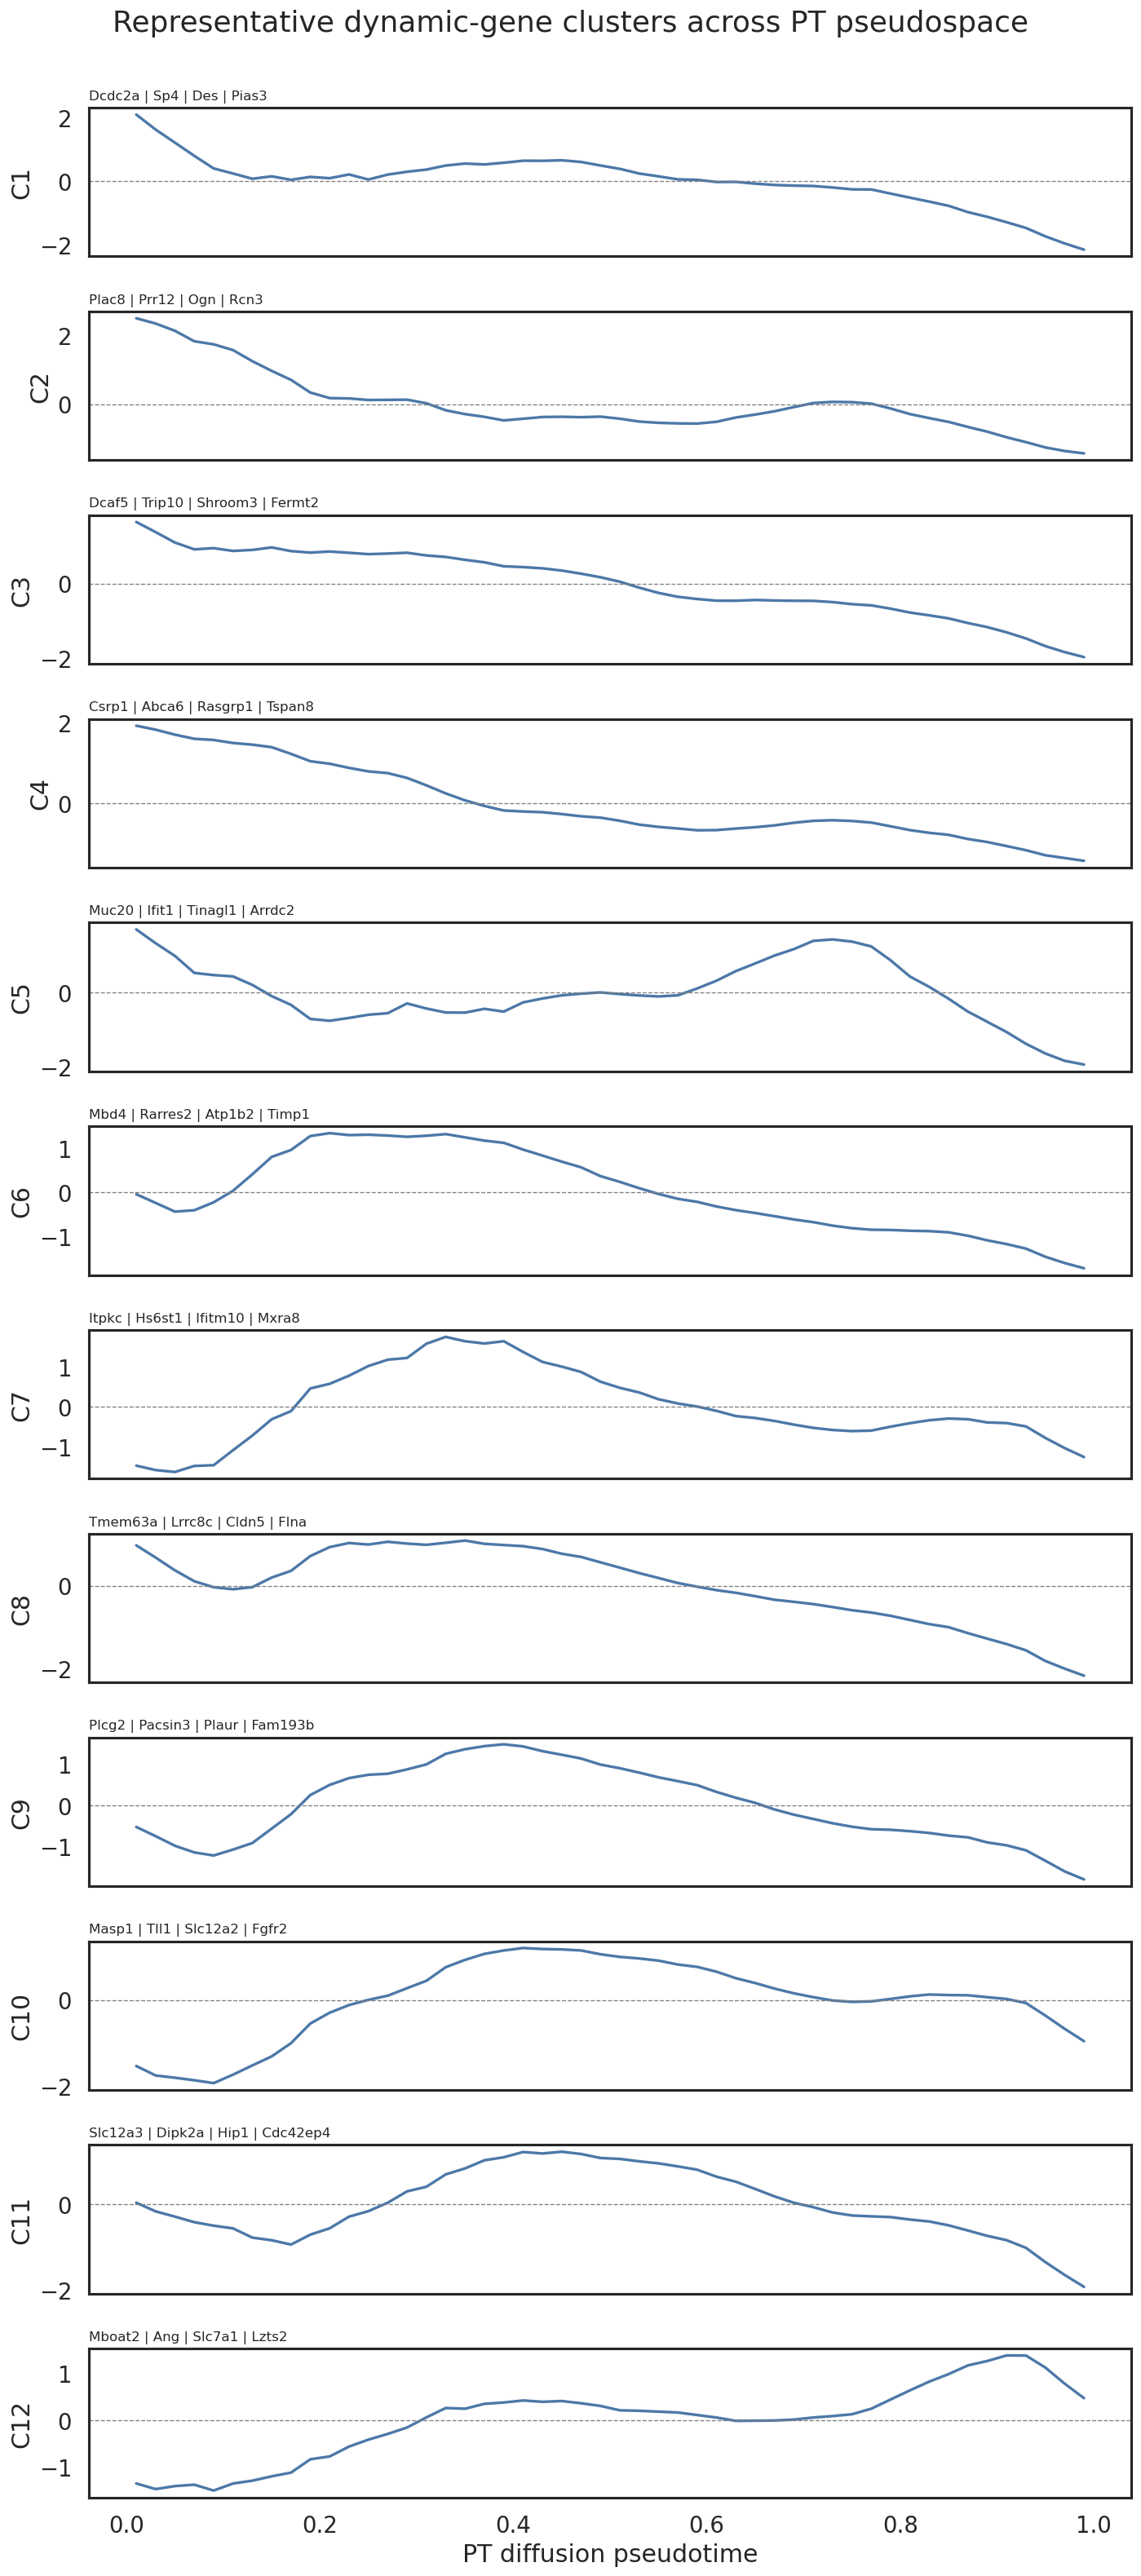

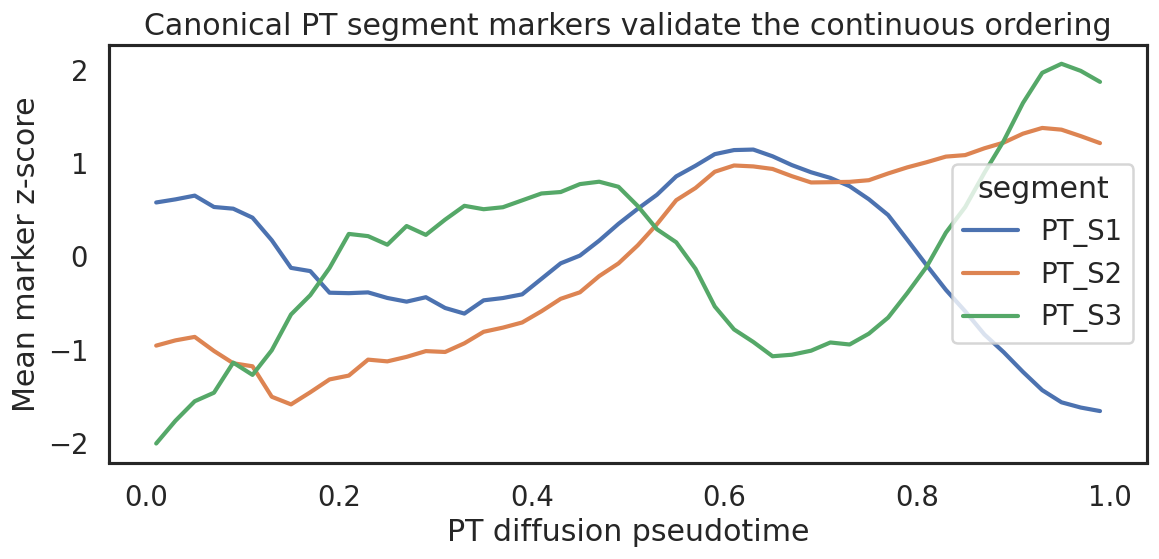

2026-05-27 20:46:59,041 [WARNING] Input library not found: KEGG_2021_Mouse. Skip


Skipping KEGG_2021_Mouse for cluster 1 because enrichr failed: No GeneSets are valid !!! Check your gene_sets input.
Skipping MSigDB_Hallmark_2020 for cluster 1 because enrichr failed: Error sending gene list, status code: 429


2026-05-27 20:46:59,609 [WARNING] Input library not found: KEGG_2021_Mouse. Skip


Skipping KEGG_2021_Mouse for cluster 2 because enrichr failed: No GeneSets are valid !!! Check your gene_sets input.
Skipping Reactome_2022 for cluster 2 because enrichr failed: Error sending gene list, status code: 429


2026-05-27 20:47:00,283 [WARNING] Input library not found: KEGG_2021_Mouse. Skip


...

2026-05-27 20:47:03,151 [WARNING] Input library not found: KEGG_2021_Mouse. Skip


Skipping GO_Biological_Process_2023 for cluster 11 because enrichr failed: Error sending gene list, status code: 429
Skipping KEGG_2021_Mouse for cluster 11 because enrichr failed: No GeneSets are valid !!! Check your gene_sets input.


2026-05-27 20:47:03,728 [WARNING] Input library not found: KEGG_2021_Mouse. Skip


Skipping KEGG_2021_Mouse for cluster 12 because enrichr failed: No GeneSets are valid !!! Check your gene_sets input.
Skipping Reactome_2022 for cluster 12 because enrichr failed: Error sending gene list, status code: 429


,cluster,library,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,1,GO_Biological_Process_2023,GO_Biological_Process_2023,Regulation Of Heart Contraction (GO:0008016),4/69,0.000396,0.185988,0,0,12.714744,99.593997,DES;KCNQ1;CALM2;SCN1B
1,1,GO_Biological_Process_2023,GO_Biological_Process_2023,Regulation Of Cell Population Proliferation (G...,12/766,0.000438,0.185988,0,0,3.462624,26.780492,TBRG1;CEBPA;NUAK1;SERTAD1;APC;ADAMTS1;HES1;CLU...
2,1,GO_Biological_Process_2023,GO_Biological_Process_2023,Positive Regulation Of Programmed Cell Death (...,6/245,0.001452,0.237111,0,0,5.250868,34.314590,APC;GBP2;CLU;PHLDA3;SAV1;BOK
3,1,GO_Biological_Process_2023,GO_Biological_Process_2023,Detection Of Calcium Ion (GO:0005513),2/12,0.001581,0.237111,0,0,40.591837,261.803919,STIM1;CALM2
4,1,GO_Biological_Process_2023,GO_Biological_Process_2023,Negative Regulation Of Cell Population Prolife...,7/379,0.002940,0.237111,0,0,3.951208,23.032730,TBRG1;CEBPA;APC;ADAMTS1;HES1;PTPN14;SAV1
...,...,...,...,...,...,...,...,...,...,...,...,...
155,12,MSigDB_Hallmark_2020,MSigDB_Hallmark_2020,KRAS Signaling Up,3/200,0.005960,0.018733,0,0,8.853090,45.350942,PLAT;ANGPTL4;CSF2RA
156,12,MSigDB_Hallmark_2020,MSigDB_Hallmark_2020,Inflammatory Response,3/200,0.005960,0.018733,0,0,8.853090,45.350942,RTP4;RGS1;SLC7A1
157,12,MSigDB_Hallmark_2020,MSigDB_Hallmark_2020,Coagulation,2/138,0.026890,0.073948,0,0,8.330672,30.123646,PLAT;ANG
158,12,MSigDB_Hallmark_2020,MSigDB_Hallmark_2020,Mitotic Spindle,2/199,0.052260,0.105455,0,0,5.733430,16.922381,SUN2;TAOK2


In [9]:
result = run_dynamic_permutation_test(adata_pt, CONFIG)
result['stats'].to_csv(OUTPUT_DIR / 'pt_dynamic_gene_stats.csv', index=False)

clustering = cluster_dynamic_genes(result, CONFIG)
clustering['ordered_dynamic_stats'].to_csv(OUTPUT_DIR / 'pt_dynamic_gene_clusters.csv', index=False)
clustering['representative_df'].to_csv(OUTPUT_DIR / 'pt_cluster_representative_genes.csv', index=False)

marker_validation = build_marker_validation_table(result, PT_MARKER_GROUPS, scale=CONFIG['marker_validation_scale'])
if not marker_validation.empty:
    marker_validation.to_csv(OUTPUT_DIR / 'pt_marker_validation_curves.csv', index=False)

plot_summary_panels(adata_pt, result, clustering, marker_validation, OUTPUT_DIR)

enrichment_results = run_gseapy_enrichment_by_cluster(
    clustering['ordered_dynamic_stats'],
    CONFIG['enrichr_libraries'],
    OUTPUT_DIR,
    organism='mouse',
)
if not enrichment_results.empty:
    top_terms = (
        enrichment_results.groupby(['cluster', 'library'], group_keys=False)
        .head(CONFIG['enrichment_top_terms'])
        .reset_index(drop=True)
    )
    display(top_terms)
else:
    print('No gseapy/Enrichr enrichment table was produced.')